# HRP (Hierarchical Risk Parity) — Notebook pedagógico (manual, paso a paso)

Este notebook implementa **HRP manualmente**, mostrando cada etapa:

1. Construcción de retornos
2. Covarianza y correlación
3. Matriz de distancias (desde correlaciones)
4. Clustering jerárquico + dendrograma
5. **Quasi-diagonalization** (reordenamiento por el árbol)
6. **Recursive bisection** (asignación de pesos por clusters)

> Nota: HRP **no usa** retornos esperados $\mu$ y **no invierte** $\Sigma$.  
> Trabaja con estructura de correlaciones/covarianzas y diversificación jerárquica del riesgo.

> Resources:
> - [Paridad de Riesgo Jerárquica (HRP)](https://www.youtube.com/watch?v=9MSPeAYBYIY).
> - [Asignación de activos - Paridad de riesgo jerárquica](https://www.youtube.com/watch?v=e21MfMe5vtU)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

try:
    from pypfopt.hierarchical_portfolio import HRPOpt
    HAS_PYPOPT = True
except Exception:
    HAS_PYPOPT = False

print("HAS_PYPOPT =", HAS_PYPOPT)


HAS_PYPOPT = True


## 0) Cargar precios 

In [2]:
import pandas as pd
from datetime import datetime, timedelta
from src.domain.etl.services.pipeline_service import FeaturePipelineService
from src.infrastructure.data.yfinance import YFinanceService
from src.domain.etl.services.extractor_service import ExtractorService
from src.domain.etl.services.enricher_service import EnricherService

yfs = YFinanceService()
extractor = ExtractorService(yfs)
enricher = EnricherService()
pipeline = FeaturePipelineService(extractor, enricher)

end = datetime.now()
start = end - timedelta(hours=4320)

data = await pipeline.start(symbols=None, timeframe="1h", start=start, end=end, indicators=["rsi"])

adj_close_frames = []
for symbol, enriched in data.items():
    df = enriched.ohlcv[["adj_close"]].copy()
    df.rename(columns={"adj_close": symbol}, inplace=True)
    adj_close_frames.append(df)

prices_df= pd.concat(adj_close_frames, axis=1).sort_index()
prices_df.head()




,AAPL.BA,TSLA.BA,MSFT.BA,NVDA.BA,BABA.BA,MELI.BA,SPY.BA,QQQ.BA
timestamp,,,,,,,,
2025-06-19 14:00:00,11575.0,25000.0,18500.0,6980.0,14575.0,23600.0,35025.0,30950.0
2025-06-19 15:00:00,11550.0,24950.0,18375.0,6960.0,14550.0,23500.0,34825.0,30650.0
2025-06-19 16:00:00,11525.0,25100.0,18400.0,6940.0,14575.0,23525.0,34775.0,30725.0
2025-06-19 17:00:00,11475.0,24975.0,18425.0,6940.0,14575.0,23500.0,34850.0,30650.0
2025-06-19 18:00:00,11525.0,24900.0,18500.0,6930.0,14525.0,23250.0,34900.0,30600.0


## 1) Retornos

HRP no optimiza retornos esperados, pero utiliza **retornos históricos**
para estimar la estructura de dependencia entre activos
(covarianzas y correlaciones).

A partir de precios \(P_t\), podemos definir:

- **Retorno simple**
$$
r_t = \frac{P_t}{P_{t-1}} - 1
$$

- **Log-retorno**
$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

Los log-retornos suelen preferirse por sus propiedades estadísticas
(aditividad temporal y mayor estabilidad ante grandes variaciones),
aunque para el cálculo de correlaciones ambas definiciones suelen
dar resultados similares en la práctica.


In [3]:
USE_LOG_RETURNS = True

if USE_LOG_RETURNS:
    returns = np.log(prices_df / prices_df.shift(1)).dropna()
else:
    returns = prices_df.pct_change().dropna()

returns.describe().T[["mean", "std", "min", "max"]].head()


,mean,std,min,max
AAPL.BA,0.000805,0.008496,-0.082960,0.037683
TSLA.BA,0.000910,0.014089,-0.091311,0.106768
MSFT.BA,0.000364,0.008387,-0.075851,0.060298
NVDA.BA,0.000654,0.011675,-0.073287,0.054528
BABA.BA,0.000771,0.012571,-0.073804,0.098222


## 2) Covarianza y correlación

- $\Sigma$: **matriz de covarianzas de los retornos**, donde

$$
\Sigma_{ij} = \mathrm{Cov}(R_i, R_j)
$$


- $\rho$: **matriz de correlaciones de los retornos**, donde

$$
\rho_{ij} = \frac{\Sigma_{ij}}{\sqrt{\Sigma_{ii}\Sigma_{jj}}}
$$



HRP usa estas matrices para entender la estructura de co-movimiento entre activos.


cov shape: (8, 8)
corr shape: (8, 8)


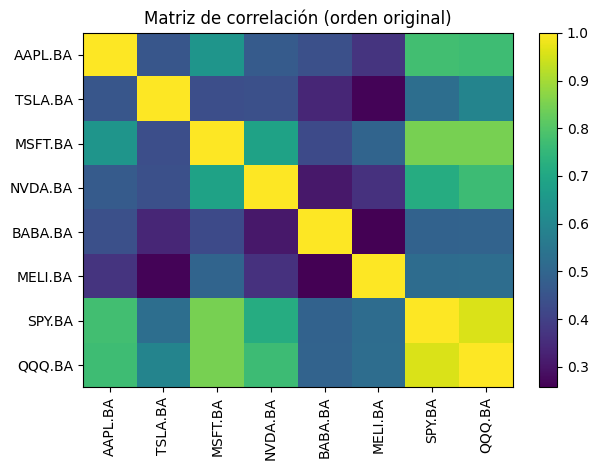

In [4]:
cov = returns.cov()
corr = returns.corr()

print("cov shape:", cov.shape)
print("corr shape:", corr.shape)

# Heatmap simple de correlaciones
plt.figure()
plt.imshow(corr.values, aspect="auto")
plt.title("Matriz de correlación (orden original)")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.tight_layout()
plt.show()


## 3) Distancia desde correlación

Una distancia típica para clustering (usada en HRP) es:

$$
d_{ij} = \sqrt{\frac{1 - \rho_{ij}}{2}}
$$

- Si $\rho_{ij} = 1$ → $d_{ij} = 0$ (activos idénticos)  
- Si $\rho_{ij} = 0$ → $d_{ij} = \sqrt{1/2}$ (no correlacionados)  
- Si $\rho_{ij} = -1$ → $d_{ij} = 1$ (movimiento opuesto)


In [5]:
dist = np.sqrt((1 - corr).clip(lower=-1, upper=1) / 2)

# squareform valida simetría y diagonal cero.
dist_condensed = squareform(dist.values, checks=False)

dist.iloc[:8, :8]


,AAPL.BA,TSLA.BA,MSFT.BA,NVDA.BA,BABA.BA,MELI.BA,SPY.BA,QQQ.BA
AAPL.BA,0.000000,0.521003,0.422175,0.513857,0.530243,0.561460,0.336061,0.339254
TSLA.BA,0.521003,0.000000,0.531340,0.529771,0.575988,0.606458,0.487251,0.450924
MSFT.BA,0.422175,0.531340,0.000000,0.396675,0.536267,0.501698,0.276872,0.276579
NVDA.BA,0.513857,0.529771,0.396675,0.000000,0.588970,0.564865,0.376766,0.341101
BABA.BA,0.530243,0.575988,0.536267,0.588970,0.000000,0.609360,0.504191,0.502633
MELI.BA,0.561460,0.606458,0.501698,0.564865,0.609360,0.000000,0.489712,0.487742
SPY.BA,0.336061,0.487251,0.276872,0.376766,0.504191,0.489712,0.000000,0.143634
QQQ.BA,0.339254,0.450924,0.276579,0.341101,0.502633,0.487742,0.143634,0.000000


## 4) Clustering jerárquico + dendrograma

Aplicamos linkage sobre la distancia. El método `single` es común en HRP (también `ward`, `average`).

El dendrograma nos muestra el **árbol de clusters**.


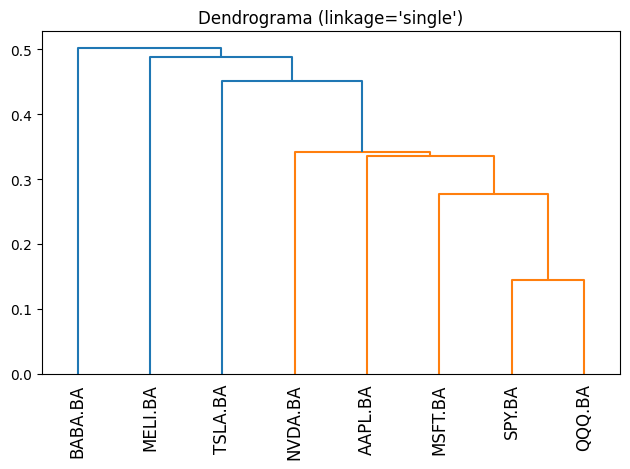

In [6]:
LINKAGE_METHOD = "single"  # "single", "average", "complete", "ward"

Z = linkage(dist_condensed, method=LINKAGE_METHOD)

plt.figure()
dendrogram(Z, labels=corr.columns.tolist(), leaf_rotation=90)
plt.title(f"Dendrograma (linkage='{LINKAGE_METHOD}')")
plt.tight_layout()
plt.show()


## 5) Quasi-diagonalization (reordenamiento por el árbol)

La idea es reordenar los activos para que los que son similares (por el clustering) queden juntos.
Esto produce una matriz (cov/corr) con estructura por bloques.

Implementamos el orden de hojas a partir del linkage.


In [7]:
def get_quasi_diag_order(Z: np.ndarray, labels: List[str]) -> List[str]:
    """Devuelve el orden de hojas del dendrograma (quasi-diagonalization)."""
    dendro = dendrogram(Z, labels=labels, no_plot=True)
    return dendro["ivl"]  # ordered labels

ordered_labels = get_quasi_diag_order(Z, corr.columns.tolist())
ordered_labels


['BABA.BA',
 'MELI.BA',
 'TSLA.BA',
 'NVDA.BA',
 'AAPL.BA',
 'MSFT.BA',
 'SPY.BA',
 'QQQ.BA']

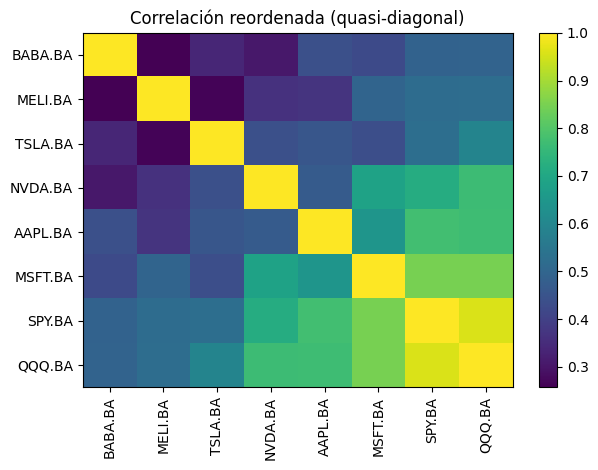

In [8]:
# Reordenamos matrices
cov_q = cov.loc[ordered_labels, ordered_labels]
corr_q = corr.loc[ordered_labels, ordered_labels]

plt.figure()
plt.imshow(corr_q.values, aspect="auto")
plt.title("Correlación reordenada (quasi-diagonal)")
plt.colorbar()
plt.xticks(range(len(ordered_labels)), ordered_labels, rotation=90)
plt.yticks(range(len(ordered_labels)), ordered_labels)
plt.tight_layout()
plt.show()


## 6) IVP dentro de un cluster (Inverse-Variance Portfolio)

Dentro de cada cluster, HRP utiliza un **Inverse-Variance Portfolio (IVP)**
para estimar el riesgo agregado del cluster.

Los pesos IVP se definen como:

$$
w_i \propto \frac{1}{\sigma_i^2}
$$

donde

$$
\sigma_i^2 = \Sigma_{ii}
$$

Normalizando, los pesos dentro del cluster quedan:

$$
w_i = \frac{\frac{1}{\sigma_i^2}}{\sum_{j \in C} \frac{1}{\sigma_j^2}}
$$

donde $C$ denota el conjunto de activos del cluster.

Con estos pesos, la **varianza del cluster** se calcula como:

$$
\sigma_C^2 = \mathbf{w}_C^\top \Sigma_C \mathbf{w}_C
$$

donde $\Sigma_C$ es la submatriz de covarianzas correspondiente al cluster.


In [9]:
def ivp_weights(cov_sub: pd.DataFrame) -> pd.Series:
    """Pesos inverse-variance normalizados dentro de un cluster."""
    diag = np.diag(cov_sub.values)
    inv_var = 1.0 / diag
    w = inv_var / inv_var.sum()
    return pd.Series(w, index=cov_sub.index)

def cluster_variance(cov_sub: pd.DataFrame) -> float:
    """Varianza del cluster usando pesos IVP dentro del cluster."""
    w = ivp_weights(cov_sub).values.reshape(-1, 1)
    return float(w.T @ cov_sub.values @ w)

# Ejemplo: varianza del cluster formado por los primeros 4 activos del orden quasi-diagonal
test_cluster = ordered_labels[:4]
print("cluster:", test_cluster)
print(f"IVP weights:", ivp_weights(cov_q.loc[test_cluster, test_cluster]))
print("cluster variance:", cluster_variance(cov_q.loc[test_cluster, test_cluster]))


cluster: ['BABA.BA', 'MELI.BA', 'TSLA.BA', 'NVDA.BA']
IVP weights: BABA.BA    0.223481
MELI.BA    0.339524
TSLA.BA    0.177919
NVDA.BA    0.259076
dtype: float64
cluster variance: 6.90906496673845e-05


/var/folders/fh/_f8pfpwx3mv0tm7n6vzq25b00000gn/T/ipykernel_68352/3630399340.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(w.T @ cov_sub.values @ w)


## 7) Recursive bisection (asignación de pesos en HRP)

Este es el paso central del algoritmo HRP: **la asignación jerárquica de pesos**
mediante una bisección recursiva de los clusters.

Se comienza con un peso total igual a 1 asignado al conjunto completo de activos.
Luego, en cada nivel de la jerarquía:

1. Se toma un cluster $C$ (conjunto de activos) y se divide en dos subclusters:
   - subcluster izquierdo $L$
   - subcluster derecho $R$

2. Se calcula la varianza de cada subcluster,
   $\sigma_L^2$ y $\sigma_R^2$,
   utilizando pesos IVP dentro de cada subcluster.

3. El peso del cluster $C$ se reparte entre $L$ y $R$
   **en proporción inversa a su riesgo**, de acuerdo a:

$$
\alpha_L = \frac{\sigma_R^2}{\sigma_L^2 + \sigma_R^2},
\qquad
\alpha_R = \frac{\sigma_L^2}{\sigma_L^2 + \sigma_R^2}
$$

4. Los pesos de los activos pertenecientes a cada subcluster
   se multiplican por $\alpha_L$ o $\alpha_R$, respectivamente.

Este procedimiento se aplica **recursivamente**
hasta que cada cluster contenga un único activo,
momento en el cual se obtiene el peso final de cada activo.

Para realizar la bisección de forma consistente con la estructura de dependencias,
se utiliza el **orden quasi-diagonal** derivado del clustering jerárquico.
En HRP, dicho orden proviene del dendrograma;
dividir la lista ordenada en mitades preserva la estructura jerárquica.


In [10]:
def recursive_bisection(cov_mat: pd.DataFrame, ordered_assets: List[str]) -> pd.Series:
    """Implementación manual de HRP (recursive bisection) sobre el orden quasi-diagonal."""
    w = pd.Series(1.0, index=ordered_assets)

    clusters = [ordered_assets]  
    while clusters:
        cluster = clusters.pop(0)
        if len(cluster) <= 1:
            continue

        # bisección
        split = len(cluster) // 2
        left = cluster[:split]
        right = cluster[split:]

        cov_left = cov_mat.loc[left, left]
        cov_right = cov_mat.loc[right, right]

        var_left = cluster_variance(cov_left)
        var_right = cluster_variance(cov_right)

        # asignación inversa al riesgo
        alpha_left = var_right / (var_left + var_right)
        alpha_right = 1.0 - alpha_left

        # aplicar asignación a los pesos actuales de cada lado
        w[left] *= alpha_left
        w[right] *= alpha_right

        # continuar recursivamente
        clusters.append(left)
        clusters.append(right)

    # normalizar a 1
    w = w / w.sum()
    return w

w_hrp_manual = recursive_bisection(cov_q, ordered_labels)
w_hrp_manual.sort_values(ascending=False)


/var/folders/fh/_f8pfpwx3mv0tm7n6vzq25b00000gn/T/ipykernel_68352/3630399340.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(w.T @ cov_sub.values @ w)
/var/folders/fh/_f8pfpwx3mv0tm7n6vzq25b00000gn/T/ipykernel_68352/3630399340.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(w.T @ cov_sub.values @ w)
/var/folders/fh/_f8pfpwx3mv0tm7n6vzq25b00000gn/T/ipykernel_68352/3630399340.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  retu

SPY.BA     0.157848
MELI.BA    0.155975
QQQ.BA     0.137560
MSFT.BA    0.136904
AAPL.BA    0.133436
NVDA.BA    0.104112
BABA.BA    0.102666
TSLA.BA    0.071499
dtype: float64

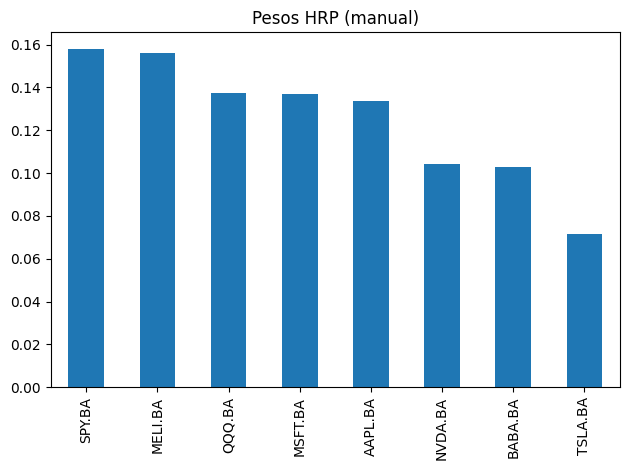

sum(weights) = 1.0
min/max weight = 0.07149878638740041 0.15784800451974626


In [11]:
plt.figure()
w_hrp_manual.sort_values(ascending=False).plot(kind="bar")
plt.title("Pesos HRP (manual)")
plt.tight_layout()
plt.show()

print("sum(weights) =", float(w_hrp_manual.sum()))
print("min/max weight =", float(w_hrp_manual.min()), float(w_hrp_manual.max()))


## 8) Comparación contra PyPortfolioOpt (opcional)

Esto sirve para validar que tu implementación manual “se parece” al HRP de PyPortfolioOpt.
No necesariamente va a dar EXACTAMENTE igual porque:
- PyPortfolioOpt puede usar una convención distinta de linkage o bisección
- puede haber detalles internos (por ejemplo, forma exacta del ordenamiento)

Pero deberían ser similares en estructura (clusters con pesos parecidos).


,manual,pypopt
BABA.BA,0.102666,0.102666
MELI.BA,0.155975,0.155975
TSLA.BA,0.071499,0.071499
NVDA.BA,0.104112,0.104112
AAPL.BA,0.133436,0.133436
MSFT.BA,0.136904,0.136904
SPY.BA,0.157848,0.157848
QQQ.BA,0.137560,0.137560


<Figure size 640x480 with 0 Axes>

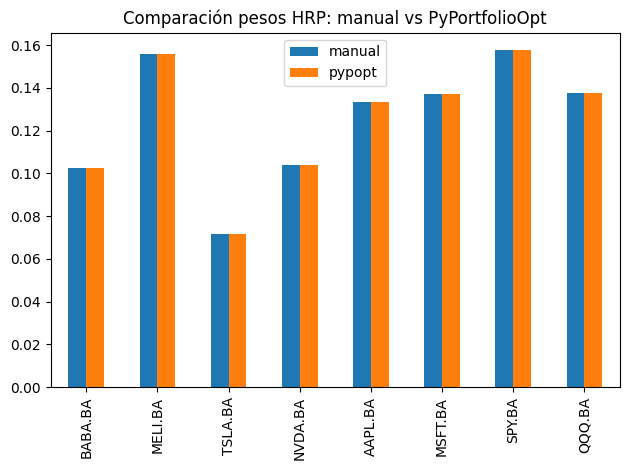

L1 distance = 2.636779683484747e-16


In [12]:
if HAS_PYPOPT:
    hrp = HRPOpt(returns)
    w_lib = pd.Series(hrp.optimize(linkage_method=LINKAGE_METHOD))
    w_lib = w_lib[w_lib > 0]
    w_lib = w_lib / w_lib.sum()

    both = pd.DataFrame({
        "manual": w_hrp_manual.reindex(w_lib.index).fillna(0.0),
        "pypopt": w_lib.reindex(w_hrp_manual.index).fillna(0.0),
    })

    both = both.loc[ordered_labels]  
    display(both)

    plt.figure()
    both.plot(kind="bar")
    plt.title("Comparación pesos HRP: manual vs PyPortfolioOpt")
    plt.tight_layout()
    plt.show()

    l1 = float(np.abs(both["manual"] - both["pypopt"]).sum())
    print("L1 distance =", l1)
else:
    print("PyPortfolioOpt no está disponible en este entorno.")


## 9) Visualización: matriz quasi-diagonal + pesos

Una forma muy pedagógica de ver HRP es:
- correlación reordenada (bloques)
- pesos en ese mismo orden

Así ves que el portafolio tiende a repartir masa entre “bloques” de activos correlacionados.


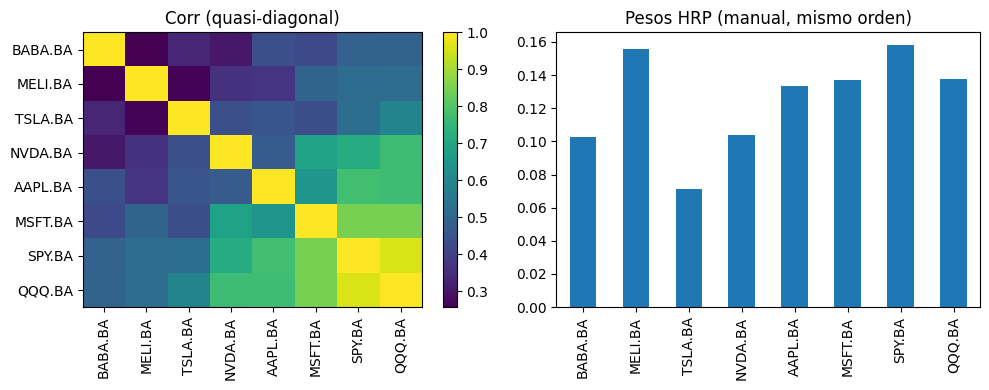

In [13]:
# Correlación reordenada + pesos en el mismo orden
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(corr_q.values, aspect="auto")
plt.title("Corr (quasi-diagonal)")
plt.colorbar()
plt.xticks(range(len(ordered_labels)), ordered_labels, rotation=90)
plt.yticks(range(len(ordered_labels)), ordered_labels)

plt.subplot(1, 2, 2)
w_hrp_manual.loc[ordered_labels].plot(kind="bar")
plt.title("Pesos HRP (manual, mismo orden)")
plt.tight_layout()
plt.show()
